# 📈 FX Time Series — A Study Workbook

A hands-on, self-contained study of **foreign-exchange (FX) time series**:
how to simulate realistic data, run exploratory data analysis (EDA), build
**cross-currency** relationships, and visualise the statistics that matter
when a rate is missing or not directly quoted.

> **Why FX is special as a time-series object**
> * FX is quoted as a **ratio of two currencies** ($EUR/USD$ = how many USD per EUR),
>   not an absolute price. Level movements are meaningless across pairs; **returns** matter.
> * Returns are close to a **random walk** at the daily horizon, but with
>   **volatility clustering** (GARCH-like), **fat tails** and occasional jumps.
> * FX trades ~24/5, so weekends/holidays create **irregular gaps** in the calendar.
> * Any cross can be **synthesised** from a triangle of other pairs when it is
>   not directly quoted — the backbone of cross-currency math and arbitrage checks.

**Plan of the workbook**

| # | Topic |
|---|-------|
| 1 | Simulate realistic FX data |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Statistics & model-free visualisations |
| 4 | Cross-currency analysis |
| 5 | Currency swaps — why, how, and what drives them |
| 6 | When a rate is *not available* (missing data / synthetic crosses) |
| 7 | Wrap-up & takeaways |


## 1 · Setup & Configuration

We use **only** libraries that ship with a typical scientific Python
environment: `pandas`, `numpy`, `matplotlib`, `seaborn`. No internet and no
specialised quant packages are required — everything is simulated locally so
the workbook is **fully reproducible**. A fixed random seed keeps the numbers
stable across runs.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RNG = np.random.default_rng(42)
np.random.seed(42)

# Presentation
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_style("whitegrid")

START = "2021-01-04"
END   = "2024-01-01"
TRADING_DAYS_PER_YEAR = 252  # ~52 weeks * 5 days

print("pandas", pd.__version__, "| numpy", np.__version__)
print("Sample window:", START, "->", END)


pandas 3.0.3 | numpy 2.4.6
Sample window: 2021-01-04 -> 2024-01-01


Levels vs returns

**Levels**
- The raw price/time series (absolute prices). Example (EUR/USD): 1.1000, 1.1050, 1.1150.

**Returns**
- The relative change between consecutive levels. Simple return: r_t = P_t / P_{t-1} - 1. Log return: r_t = ln(P_t / P_{t-1}).
- Example: P_{t-1} = 1.10, P_t = 1.15 → simple return = 1.15/1.10 - 1 = 0.04545 (4.545%), log return ≈ 0.0445.

**Why model returns instead of levels?**
- Stationarity: returns are often closer to stationary, which many statistical models assume.
- Scale-free: returns let you compare assets with different price scales.
- Additivity: log returns are additive over time (useful for aggregation).
- Volatility/risk: volatility is naturally measured on returns.

**Why keep levels?**
- Absolute decisions: stop-loss, limit orders, strikes, and drawdowns depend on price levels.
- Portfolio value and execution require actual prices.
- Some signals are defined directly on levels (e.g., moving-average crossovers, breakouts).

**Rule of thumb**: use returns for statistical modeling and risk analysis; use levels for execution, thresholds, and any rule that needs absolute prices.

Spot vs Forward — how prices are computed

**Spot price (what you see for immediate trades)**
- Definition: the current market price for immediate delivery of a currency pair (commonly settles on the spot value date, e.g. T+2 business days).
- Who sets it: continuously determined by the market (banks / ECNs / dealers) via bid/ask quotes; the mid is often used for analytics.
- Practical notes: quoted as `base/quote` (e.g., EUR/USD = 1.1000 means 1 EUR = 1.1000 USD). FX quoting uses pips/points (usually the 4th decimal for majors, 2nd for JPY pairs).

**Forward price (agreement today, settlement later)**
- Definition: price agreed today for delivery at a future date (tenor). Forward = spot adjusted for the interest-rate differential between the two currencies (covered interest parity).
- Continuous compounding formula: $$F = S \times e^{(r_{quote} - r_{base})T}$$
  - Here `S` = spot, `r_base` = interest rate of base currency, `r_quote` = interest rate of quote currency, and `T` is time in years.
- Money-market / discrete formula (common in practice): $$F = S \times \frac{1 + r_{quote} T}{1 + r_{base} T}$$
- Forward points (swap points): the difference `F - S` is often expressed in pips and added/subtracted from the spot quote to present dealer prices.

**Who computes and publishes forwards**
- Dealers/banks compute forwards using observable short-term money-market rates (deposit / OIS / LIBOR-replacement rates), day-count conventions, and the exact spot value date.
- Dealers publish forward points relative to spot; large FX platforms and data vendors aggregate these dealer quotes.
- For clients, banks quote a forward `bid/ask` (so the client sees a slightly worse forward than the mid due to dealer spread).

**Practical adjustments & gotchas**
- Spot value date (e.g. T+2) and holiday calendars: the actual settlement date affects `T` and must be business-day adjusted.
- Day-count conventions differ by currency (e.g., USD uses ACT/360 in many money-market conventions). Use the correct `T` calculation.
- Non-standard tenors are built by interpolation of market swap rates or by quoting synthetic combinations of standard tenors.
- Bid/ask: always remember forward points have their own spread — forwards are quoted as `spot + points_bid/points_ask`.

**Numeric example**
- Given: spot `S = 1.1000` (EUR/USD), USD rate `r_quote = 2.0%` pa, EUR rate `r_base = 0.5%` pa, tenor `T = 90/360 = 0.25` years.
- Continuous formula: `F = 1.1000 * exp((0.02 - 0.005) * 0.25) ≈ 1.1000 * exp(0.00375) ≈ 1.1041`.
- Forward points = `F - S ≈ 0.0041` → 41 pips (for majors with 4-decimal pip).

**Rule of thumb**: forwards are not "predictions" of the future spot — they are the no-arbitrage price implied by interest-rate differentials (covered interest parity). Use them for hedging and valuation, and remember settlement conventions and bid/ask spreads matter in practice.

In [4]:
def simulate_fx(
    start=START,
    end=END,
    level0=1.08,          # starting spot, e.g. EUR/USD
    mu=0.02,              # annualised drift
    vol0=0.08,            # mean annualised volatility
    kappa=90.0,           # vol mean-reversion speed (higher => less persistent vol)
    long_run_vol=0.09,    # long-run annualised vol
    nu=6,                 # Student-t degrees of freedom (lower => fatter tails)
    seed=42,
):
    """Simulate a daily FX spot series with clustering vol + fat tails."""
    rng = np.random.default_rng(seed)
    idx = pd.bdate_range(start=start, end=end)          # Mon-Fri calendar
    n = len(idx)
    dt = 1.0 / TRADING_DAYS_PER_YEAR

    # --- state variables -------------------------------------------------
    vol = np.empty(n)
    vol[0] = vol0
    for t in range(1, n):
        vol[t] = vol[t-1] + kappa * (long_run_vol - vol[t-1]) * dt \
                          + rng.normal(0, 0.35 * vol[t-1] * np.sqrt(dt))
    vol = np.abs(vol)                                    # vol must stay positive

    # --- fat-tailed innovations scaled to have ~unit variance -------------
    z = rng.standard_t(df=nu, size=n)
    z = z / np.std(z)                                    # standardise

    # --- log-returns: drift + vol * innovation ----------------------------
    log_ret = (mu - 0.5 * vol**2) * dt + (vol * np.sqrt(dt)) * z

    # --- level -------------------------------------------------------------
    level = level0 * np.exp(np.cumsum(log_ret))

    return pd.DataFrame({"level": level, "vol_ann": vol}, index=idx)

eurusd = simulate_fx(level0=1.08, seed=42)
print(eurusd.head().round(4))
print("\nRows:", len(eurusd), "| first:", eurusd.index[0].date(), "| last:", eurusd.index[-1].date())


             level  vol_ann
2021-01-04  1.0798   0.0800
2021-01-05  1.0843   0.0841
2021-01-06  1.0847   0.0843
2021-01-07  1.0837   0.0877
2021-01-08  1.0862   0.0904

Rows: 781 | first: 2021-01-04 | last: 2024-01-01


### Spot vs forward — the deep dive: tenors & quotes

This extends the *"Spot vs Forward"* note above with the **naming
conventions**, the **tenor ladder** and the **day-count rules** the market
actually uses.

**Spot rate ($S$)** — the rate for *immediate* settlement. For EUR/USD that is
**T+2** (two business days: trade agreed today, cash moves two days later).

**Forward rate ($F_t$)** — the rate **locked today** for an exchange on a fixed
future date $t$. You agree $F_t$ now; what spot *prints* at $t$ is irrelevant
to your contract.

**30-day vs 90-day vs 1-year — what's the difference?**
They differ only in **maturity** → only in how much of the interest-rate
differential gets compounded. A **30-day forward** settles ~1 month after spot,
a **90-day** ~3 months, the **1-year** ~12 months. All use the same spot and
the same rate gap, just a different tenor $t$.

> **Does a 30-day forward mean "we agree spot will be $X$ in 30 days"?**
> **No.** It is **not a forecast** — it is the *guaranteed* rate at which you
> will convert currencies in 30 days, no matter where spot goes. Forwards are
> practically risk-free to quote because they are **funded and hedged** via the
> rate differential, not predicted.

**Do we create a forward contract for every date?**
No. The interbank market quotes **standard tenors** (O/N, T/N, 1W, 1M, 2M, 3M,
6M, 9M, 1Y). Any other horizon is a **"broken" date**, priced by
**interpolating** swap points between the neighbouring standard tenors — so you
*can* trade any date, it just costs a little more depth.

**What are tenors / tenor days?**
A **tenor** is the time to the forward's maturity. The **tenor days** is the
actual number of **calendar days** from **spot settlement** to **forward
settlement**, used with a day-count **convention**:
* **ACT/360** — most FX (EUR, USD, JPY, CHF…): `#days / 360`.
* **ACT/365** — GBP and a few others: `#days / 365`.
* Settlement lands on a **valid business day** (*modified following*).

**Cross-currency**: the same logic applies to every pair. A cross's forward
(e.g. EUR/GBP, EUR/JPY) uses the interest rates of *both* currencies, so the
premium/discount follows that pair's **rate gap**.


In [ ]:
# --- Tenor settlement dates & tenor days (EUR/USD example) --------------------
def roll_to_bday(ts):
    while ts.dayofweek in (5, 6):            # land on a business day
        ts = ts + pd.Timedelta(days=1)
    return ts

spot_dt = pd.Timestamp("2024-01-02")         # a spot settlement date (deal before)
tenor_defs = [
    ("O/N", pd.DateOffset(days=1)),
    ("T/N", pd.DateOffset(days=1)),
    ("1W",  pd.DateOffset(days=7)),
    ("1M",  pd.DateOffset(months=1)),
    ("2M",  pd.DateOffset(months=2)),
    ("3M",  pd.DateOffset(months=3)),
    ("6M",  pd.DateOffset(months=6)),
    ("9M",  pd.DateOffset(months=9)),
    ("1Y",  pd.DateOffset(months=12)),
]

rows = []
for label, off in tenor_defs:
    sett = roll_to_bday(spot_dt + off)
    days = (sett - spot_dt).days
    rows.append({
        "tenor": label,
        "spot settlement": spot_dt.date(),
        "forward settlement": sett.date(),
        "tenor days (actual)": days,
        "days/360": round(days / 360, 4),
        "days/365": round(days / 365, 4),
    })
tenor_table = pd.DataFrame(rows)
tenor_table


In [ ]:
# --- Self-contained CIP forward helper (local to this deep-dive) -------------
def fwd_rate(spot, r_dom, r_for, days, basis=360):
    t = days / basis
    return spot * (1.0 + r_dom * t) / (1.0 + r_for * t)

# --- Forward-curve visualisation: rate AND swap points vs tenor days ----------
spot_eur = 1.08
r_eur = 0.03; r_usd = 0.05                     # USD rates > EUR => discount

std_days = tenor_table["tenor days (actual)"].to_numpy()
fwd_rates = fwd_rate(spot_eur, r_eur, r_usd, std_days)
fwd_pips  = (fwd_rates - spot_eur) * 1e4

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

# Top: forward rate vs spot
axes[0].plot(std_days, fwd_rates, marker="o", color="#1f6feb", lw=1.8, label="forward rate")
axes[0].axhline(spot_eur, color="crimson", ls="--", lw=1.2, label=f"spot {spot_eur}")
for d, r in zip(std_days, fwd_rates):
    axes[0].annotate(f"{r:.4f}", (d, r), textcoords="offset points", xytext=(0, 6), fontsize=7)
axes[0].set_ylabel("EUR/USD rate")
axes[0].set_title("EUR/USD forward curve — USD rates > EUR pulls forwards below spot")
axes[0].legend(fontsize=8)

# Bottom: swap/forward points in pips (the discount)
axes[1].bar(std_days, fwd_pips, color="#e8590c", alpha=0.85, width=10)
axes[1].axhline(0, color="k", lw=0.8)
for d, p in zip(std_days, fwd_pips):
    axes[1].annotate(f"{p:.0f}", (d, p), textcoords="offset points", xytext=(0, 5), fontsize=7)
axes[1].set_ylabel("swap points (pips)")
axes[1].set_title("Forward points — the gap grows with tenor (negative = forward discount)")

axes[1].set_xticks(std_days)
axes[1].set_xticklabels(tenor_table["tenor"], rotation=45, ha="right")
axes[1].set_xlabel("tenor (days) — labels are the standard tenors")
fig.tight_layout(); plt.show()


In [ ]:
# --- The forward is NOT a forecast of future spot ------------------------------
# Pick a trade date mid-sample; price forwards today at its spot; then compare
# with the *actual* spot that later printed (from our simulated EUR/USD).
origin = pd.Timestamp("2022-07-01")
S0 = eurusd.loc[:origin]["level"].iloc[-1]

fwd_rows = []
for _, trow in tenor_table.iterrows():
    days = trow["tenor days (actual)"]
    fwd_t = fwd_rate(S0, r_eur, r_usd, days)
    sett = roll_to_bday(origin + pd.Timedelta(days=days))     # ~ settlement date
    realized = eurusd["level"].asof(sett)                     # actual spot printed
    fwd_rows.append({"tenor": trow["tenor"], "tenor_days": days,
                     "forward_today": fwd_t, "realized_spot": realized})
frow = pd.DataFrame(fwd_rows)

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(frow["tenor_days"], frow["forward_today"], marker="o", color="#1f6feb",
        lw=1.8, label="forward agreed today")
ax.plot(frow["tenor_days"], frow["realized_spot"], marker="s", color="#d6336c",
        lw=1.8, label="spot that actually printed")
ax.axhline(S0, color="crimson", ls="--", lw=1.1, label=f"spot at trade date {S0:.4f}")
ax.set_xlabel("tenor (days)")
ax.set_ylabel("EUR/USD")
ax.set_title("Forward agreed today  vs  spot realized later — they need NOT match")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [ ]:
# --- Every date can be quoted: interpolating a "broken" tenor ------------------
# Only standard tenors have direct quotes. A 45-day trade is a *broken date*
# priced by linearly interpolating swap points between the surrounding tenors.
std_pts = (fwd_rate(spot_eur, r_eur, r_usd, std_days) - spot_eur) * 1e4

broken_days = 45
broken_pts  = float(np.interp(broken_days, std_days, std_pts))     # pips
broken_fwd  = spot_eur + broken_pts / 1e4

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(std_days, std_pts, marker="o", color="#1f6feb", lw=1.8, label="standard-tenor swap points")
ax.axvline(broken_days, color="k", ls=":", lw=1.0)
ax.scatter([broken_days], [broken_pts], color="#e8590c", zorder=5, s=90,
           label=f"broken tenor {broken_days}d")
ax.annotate(f"interpolated {broken_pts:.0f} pips -> F = {broken_fwd:.4f}",
            (broken_days, broken_pts), textcoords="offset points",
            xytext=(12, -6), fontsize=8, color="#e8590c")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("tenor (days)"); ax.set_ylabel("swap points (pips)")
ax.set_title("A broken-date forward is interpolated between standard tenors")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [ ]:
# --- Cross-currency: forwards exist for every pair -----------------------------
# The same CIP logic applies to any pair; sign & size follow that pair's rate gap.
ccfwd = {
    "EUR/USD": dict(spot=1.08,  rd=0.030, rf=0.050),   # USD > EUR  -> discount
    "USD/JPY": dict(spot=150.0, rd=0.050, rf=0.000),   # JPY ~ 0%   -> premium
    "GBP/USD": dict(spot=1.27,  rd=0.042, rf=0.050),   # USD > GBP  -> discount
    "AUD/USD": dict(spot=0.66,  rd=0.0435, rf=0.050),
    "USD/CHF": dict(spot=0.88,  rd=0.050, rf=0.012),
}
threeM = 90
cc_rows = []
for name, c in ccfwd.items():
    f = fwd_rate(c["spot"], c["rd"], c["rf"], threeM)
    cc_rows.append((name, f,
                    round((f - c["spot"]) * 1e4, 0),
                    round((f / c["spot"] - 1) * 360 / threeM * 100, 2)))
ccdf = pd.DataFrame(cc_rows, columns=["pair", "3M forward", "3M swap pips", "annualised carry %"])

fig, ax = plt.subplots(figsize=(11, 4.2))
pips = ccdf["3M swap pips"].astype(float).to_numpy()
names = ccdf["pair"].tolist()
bars = ax.bar(names, pips, color=["#d6336c" if p < 0 else "#2f9e44" for p in pips], alpha=0.85)
ax.axhline(0, color="k", lw=0.8)
for b, p in zip(bars, pips):
    ax.text(b.get_x() + b.get_width()/2, p + (2 if p >= 0 else -4), f"{p:.0f}",
            ha="center", fontsize=9)
ax.set_ylabel("3M swap points (pips)")
ax.set_title("3M forwards across pairs — sign follows the interest-rate gap")
plt.tight_layout(); plt.show()
ccdf
# =====================================================================


## 2 · Exploratory Data Analysis (EDA)

*Plot first, model later.* We inspect:

1. **Levels** — is there a visible trend/regime change?
   - What to plot: the raw price series, a couple of moving averages (e.g., 20- and 60-day), and an indexed view (start = 100) so different pairs are comparable.
   - What to look for: persistent up/down drift, sudden shifts (regime changes), step-jumps after events. If levels show clear structure, note it — but be cautious: many trends vanish once returns are used.

2. **Returns** — the stationary transformation we actually analyse.
   - Compute: `eurusd['ret'] = np.log(eurusd['level']).diff()` (log returns) or simple returns `P_t/P_{t-1}-1`.
   - Why: returns remove scale and often make the series closer to stationary; work with returns for statistics, correlation, and volatility analysis.

3. **Summary statistics** — mean, vol, skew, kurtosis, quantiles.
   - Useful metrics: daily mean, daily std, annualised vol = `std * sqrt(252)`, skew (asymmetry), excess kurtosis (tail weight), and extreme quantiles (1%, 5%).
   - Why: mean suggests drift vs noise; vol summarises risk; skew/kurtosis reveal asymmetry and fat tails that break Normal assumptions.

4. **Distribution shape** — fat tails & non-normality.
   - Plots/tests: histogram + Normal overlay, QQ-plot, empirical tail quantiles, and optionally a KS or Anderson–Darling test.
   - Why: many risk measures and models assume Normality — FX returns typically have heavier tails, so expect more extreme moves than a Normal predicts.

5. **Drawdowns** — how deep is a "bad" episode?
   - Compute: running peak `running_max = level.cummax()` and `drawdown = (level / running_max - 1) * 100` (percent).
   - Why: max drawdown and drawdown duration measure real investor pain and help size positions and set stop-losses.

6. **Autocorrelation** — is there momentum or mean-reversion?
   - Check ACF of returns (short-lag significance indicates momentum/mean-reversion) and ACF of squared returns (persistence indicates volatility clustering / GARCH effects).
   - Why: many simple forecasts fail if returns are uncorrelated, but persistent squared-return ACF signals predictable volatility useful for risk models.


> Quick checklist for a beginner EDA run:
> - Plot `level` and `level` indexed to 100.
> - Compute `ret = np.log(level).diff()` and plot time-series + histogram.
> - Print summary stats (daily mean/std, ann. vol, skew, kurtosis, 1%/5% quantiles).
> - Plot QQ-plot vs Normal and overlay a Normal PDF on the histogram.
> - Compute drawdown series and report `max drawdown` and its date.
> - Plot ACF for returns and squared returns with 95% significance bands.

In [ ]:
# --- Spot vs Forward: calculate forwards and visualise differences ----------------
# Uses eurusd['level'] (spot). Assumes constant short rates for demonstration.
r_base = 0.005   # EUR rate (annual)
r_quote = 0.02   # USD rate (annual)

def forward_from_spot(spot, r_base, r_quote, tenor_days, daycount=360, method="discrete"):
    T = tenor_days / daycount
    if method == "cont":
        return spot * np.exp((r_quote - r_base) * T)
    else:
        return spot * (1 + r_quote * T) / (1 + r_base * T)

tenors = [30, 90, 180]
for t in tenors:
    eurusd[f"F_{t}d"] = forward_from_spot(eurusd["level"], r_base, r_quote, t)

# Visualisation: spot + forwards (recent window) and forward points in pips
window = eurusd.index[-250:]
fig, axes = plt.subplots(len(tenors) + 1, 1, figsize=(11, 3 * (len(tenors) + 1)), sharex=True)

# Panel 0: Spot and forwards
axes[0].plot(eurusd.loc[window, "level"], label="Spot", color="#1f6feb", lw=1.2)
for i, t in enumerate(tenors):
    axes[0].plot(eurusd.loc[window, f"F_{t}d"], label=f"Forward {t}d", lw=0.9)
axes[0].set_title("EUR/USD: Spot and Implied Forwards (demo rates)")
axes[0].legend(loc="best", fontsize=8)
axes[0].set_ylabel("price")

# Panels 1..N: forward points (F - S) in pips
colors = ["#e8590c", "#2f9e44", "#7048e8"]
for i, t in enumerate(tenors):
    fp = (eurusd[f"F_{t}d"] - eurusd["level"]) * 10000.0  # pips for 4-decimal pairs
    axes[i + 1].plot(fp.loc[window], color=colors[i], lw=0.9)
    axes[i + 1].axhline(fp.mean(), color="k", ls="--", lw=0.8)
    axes[i + 1].set_ylabel(f"{t}d points (pips)")
    # sensible y-limits to focus on bulk of distribution
    qlo, qhi = fp.loc[window].quantile(0.01), fp.loc[window].quantile(0.99)
    axes[i + 1].set_ylim(qlo, qhi)

fig.tight_layout()
plt.show()

# Print a small numeric summary (last values)
print(f"Last spot: {eurusd['level'].iloc[-1]:.6f}")
for t in tenors:
    fval = eurusd[f"F_{t}d"].iloc[-1]
    pts  = (fval - eurusd["level"].iloc[-1]) * 10000.0
    print(f"Forward {t}d last: {fval:.6f} | points: {pts:.2f} pips")

# Interpretation note for the notebook user
print("\nInterpretation: forwards reflect interest-rate differentials, not forecasts of spot.")
print("Positive points -> forward > spot (quote currency yields more than base).")

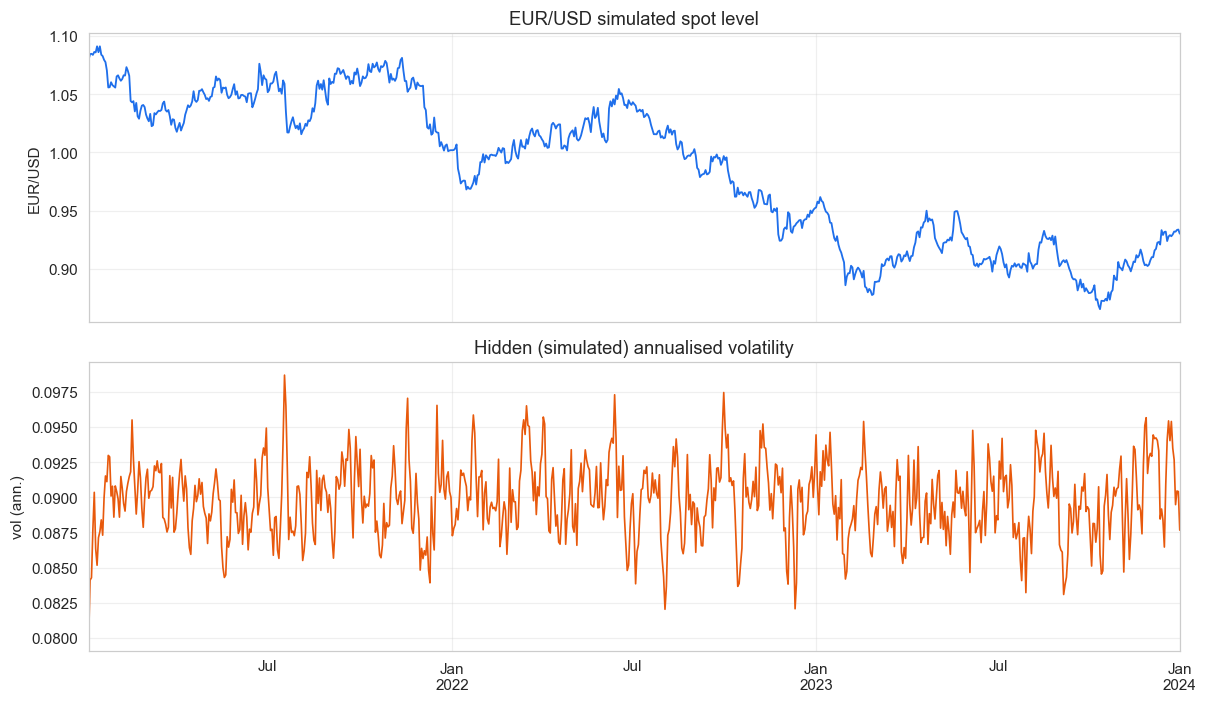

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

# Panel 1: level
eurusd["level"].plot(ax=axes[0], color="#1f6feb", lw=1.2, title="EUR/USD simulated spot level")
axes[0].set_ylabel("EUR/USD")

# Panel 2: annualised rolling volatility (drives the "regime" feel)
eurusd["vol_ann"].plot(ax=axes[1], color="#e8590c", lw=1.1, title="Hidden (simulated) annualised volatility")
axes[1].set_ylabel("vol (ann.)")
fig.tight_layout()
plt.show()


In [ ]:
# --- Returns: log returns are the analyst's bread & butter ------------------
eurusd["ret"] = np.log(eurusd["level"]).diff()
eurusd.dropna(inplace=True)

# --- First rows of levels + returns ----------------------------------------
eurusd.head()


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5))
eurusd["ret"].plot(ax=axes[0], color="#2f9e44", lw=0.8, title="EUR/USD daily log returns")
axes[0].set_ylabel("log return")

eurusd["ret"].hist(bins=80, ax=axes[1], color="#2f9e44", alpha=0.8, density=True)
axes[1].set_title("Histogram of daily returns (vs. Normal overlay)")
axes[1].set_ylabel("density")

xs = np.linspace(eurusd["ret"].min(), eurusd["ret"].max(), 400)
mu_s, sd_s = eurusd["ret"].mean(), eurusd["ret"].std()
nexp = np.exp(-0.5 * ((xs - mu_s) / sd_s) ** 2) / (sd_s * np.sqrt(2 * np.pi))
axes[1].plot(xs, nexp, color="crimson", lw=2, ls="--", label="Normal(mean,std)")
axes[1].legend()
fig.tight_layout()
plt.show()


In [ ]:
# --- A multi-pair panel: several majors, indexed so relative moves compare ----
majors = {
    "EUR/USD": dict(level0=1.08, seed=42),
    "GBP/USD": dict(level0=1.27, seed=7),
    "USD/JPY": dict(level0=150.0, seed=123),
    "AUD/USD": dict(level0=0.66, seed=99),
    "USD/CHF": dict(level0=0.88, seed=555),
}

px  = pd.DataFrame({pair: simulate_fx(**cfg)["level"] for pair, cfg in majors.items()})
ret = np.log(px).diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5))
(px / px.iloc[0] * 100).plot(ax=axes[0], title="All pairs, indexed to 100 (start)")
axes[0].set_ylabel("index (start = 100)")
axes[0].legend(loc="best", ncol=3, fontsize=8)

ret.plot(ax=axes[1], alpha=0.7, lw=0.8, title="Daily log returns")
axes[1].set_ylabel("log return")
fig.tight_layout()
plt.show()


### Summary statistics — the numbers behind the chart

`skew` (asymmetry) and `kurtosis` (tail weight) are the classic FX diagnostics:
* A **positive kurtosis** (excess > 0) means fatter tails than a Normal.
* **skew** tells you whether big up-moves or big down-moves predominate.

We also standardise with `annualised volatility = std × √252`.


In [ ]:
def describe_fx(s):
    """Compact, analyst-focused summary for a return series."""
    ann_vol = s.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
    c = s.dropna()
    n = len(c)
    excess_kurt = (c - c.mean()).pow(4).mean() / (c.std()**4) - 3.0
    skew = ((c - c.mean()) / c.std()).pow(3).mean()
    return pd.Series({
        "n": n,
        "annualized_return": (np.exp(c.mean() * 252) - 1),
        "daily_mean": c.mean(),
        "daily_std": c.std(),
        "annualized_vol": ann_vol,
        "skew": skew,
        "excess_kurtosis": excess_kurt,
        "min": c.min(),
        "max": c.max(),
        "q25": c.quantile(0.25),
        "median": c.median(),
        "q75": c.quantile(0.75),
    })

descr = pd.DataFrame({pair: describe_fx(ret[pair]) for pair in ret.columns}).T
descr.round(5)


In [ ]:
# --- ACF: autocorrelation of returns AND squared returns ---------------------
# Squared returns proxy for "volatility": if their ACF is large & persistent,
# that is the statistical fingerprint of volatility clustering / GARCH.

def autocorr(x, max_lag=25):
    x = x - x.mean()
    var = np.sum(x ** 2)
    if var == 0:
        return np.full(max_lag, np.nan)
    return np.array([np.sum(x[l:] * x[:-l]) / var for l in range(1, max_lag + 1)])

max_lag = 25
acf_ret  = autocorr(eurusd["ret"], max_lag)
acf_ret2 = autocorr(eurusd["ret"] ** 2, max_lag)
se = 1.0 / np.sqrt(len(eurusd))                 # ~95% band

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, vals, title in [
    (axes[0], acf_ret,  "ACF of daily returns"),
    (axes[1], acf_ret2, "ACF of squared returns (volatility clustering)"),
]:
    ax.bar(range(1, max_lag + 1), vals, color="#1f6feb", alpha=0.8)
    ax.axhline(0, color="k", lw=0.8)
    ax.axhline(+1.96 * se, color="crimson", ls="--", lw=1)
    ax.axhline(-1.96 * se, color="crimson", ls="--", lw=1)
    ax.set_title(title)
    ax.set_xlabel("lag")
    ax.set_ylabel("ACF")
fig.tight_layout()
plt.show()


> **Reading the ACF plot**: daily *returns* are usually near-white noise (ACF
> ~ 0), while *squared* returns show strong positive, slowly-decaying ACF. That
> asymmetry — **"returns unpredictable, variance predictable"** — is the defining
> stylised fact of FX and justifies vol models, not simple trend models.


In [ ]:
# --- Drawdown: peak-to-trough decline from running peak ----------------------
level = eurusd["level"]
running_max = level.cummax()
drawdown = (level / running_max - 1.0) * 100

fig, ax = plt.subplots(figsize=(11, 4))
drawdown.plot(ax=ax, color="#d6336c", lw=1.0)
ax.fill_between(drawdown.index, 0, drawdown, color="#d6336c", alpha=0.15)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("drawdown (%)")
ax.set_title("EUR/USD drawdown from running peak (%)")
worst = drawdown.idxmin()
ax.annotate(f"max DD {drawdown.min():.1f}%\n{worst.date()}",
            xy=(worst, drawdown.min()), xytext=(-60, -60),
            textcoords="offset points", arrowprops=dict(arrowstyle="->", color="k"))
fig.tight_layout()
plt.show()
print(f"Max drawdown: {drawdown.min():.1f}% on {worst.date()}")


## 3 · Statistics to visualise FX series

Beyond a single pair, we visualise:
* **Rolling volatility** — how risk evolves through time (and across pairs).
* **Correlation matrix** — cross-currency co-movement / risk clustering.
* **Rolling correlation** — does the covariance regime shift over time?

> **Rule of thumb**: annualised vol is more comparable across FX pairs than
> raw daily std, because daily counts differ little between pairs (~252).
> For *crosses* involving JPY the scale differs — always compare on returns.


In [ ]:
# --- Rolling annualised volatility across the majors -------------------------
win = 60
rolling_vol = ret.rolling(win).std() * np.sqrt(TRADING_DAYS_PER_YEAR) * 100

ax = rolling_vol.plot(figsize=(11, 4.5), lw=1.1, title=f"Rolling {win}-day annualised volatility (%)")
ax.set_ylabel("ann. vol (%)")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
# --- Correlation heatmaps: full-sample vs. rolling ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

sns.heatmap(ret.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title("Full-sample return correlation")

# Rolling correlation of EUR/USD vs USD/JPY — shows regime shifts
roll_corr = ret["EUR/USD"].rolling(win).corr(ret["USD/JPY"])
roll_corr.plot(ax=axes[1], color="#1f6feb", lw=1.1)
axes[1].axhline(ret["EUR/USD"].corr(ret["USD/JPY"]), color="crimson", ls="--",
                label="full-sample corr")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title(f"Rolling {win}-day corr EUR/USD vs USD/JPY")
axes[1].set_ylim(-1, 1)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


## 4 · Cross-currency analysis

A **cross** is any FX pair that does not involve the US dollar, e.g. EUR/GBP,
EUR/JPY, AUD/NZD. The market quotes a small set of **base pairs** and *derives*
or *price-arbitrages* the rest. This section shows:

1. The **relationship between pairs** (which base builds which cross).
2. **Synthetic construction** of a cross from a triangle of available pairs.
3. **Triangular-consistency check** — the arbitrage condition.
4. What happens **when a rate is not available** (the whole point of crosses).


### The cross-currency triangle

A simple, powerful identity: if we know `EUR/USD` and `USD/JPY`, then

$$\text{EUR/JPY} = \text{EUR/USD} \times \text{USD/JPY}$$

i.e. $EUR/JPY = (EUR/USD)\cdot(USD/JPY)$. Similarly the *inverse* and any
intermediate pair from the closed triangle. Because FX is arbitraged, the
market keeps these identities (almost) exact.


In [ ]:
# --- Reconstruct the majors cleanly -----------------------------------------
# We already simulated EUR/USD, USD/JPY, GBP/USD in `px`. Build a cross table
# combining an authenticated triangle that MUST be internally consistent.

eurusd_px   = px["EUR/USD"]
usdjpy_px   = px["USD/JPY"]
gbpusd_px   = px["GBP/USD"]

# --- Synthetic EUR/JPY from the triangle ------------------------------------
eurjpy_synth = eurusd_px * usdjpy_px          # EUR/USD * USD/JPY  == EUR/JPY

# --- EUR/GBP from the triangle ----------------------------------------------
eurgbp_synth = eurusd_px / gbpusd_px          # EUR/USD / GBP/USD  == EUR/GBP

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
eurjpy_synth.plot(ax=axes[0], color="#7048e8", lw=1.1, title="Synthetic EUR/JPY  =  EUR/USD × USD/JPY")
axes[0].set_ylabel("EUR/JPY")
eurgbp_synth.plot(ax=axes[1], color="#1971c2", lw=1.1, title="Synthetic EUR/GBP  =  EUR/USD ÷ GBP/USD")
axes[1].set_ylabel("EUR/GBP")
fig.tight_layout()
plt.show()

cross = pd.DataFrame({"EUR/JPY": eurjpy_synth, "EUR/GBP": eurgbp_synth})
cross.tail(6).round(4)


In [ ]:
# --- Triangular consistency: reconstruct EUR/USD back from the cross --------
# EUR/USD == EUR/GBP * GBP/USD
eurusd_back = eurgbp_synth * gbpusd_px
max_gap = (eurusd_back / eurusd_px - 1.0).abs().max()

print("Max relative reconstruction gap (EUR/USD via EUR/GBP * GBP/USD):")
print(f"  {max_gap:.3e}")
print("-> Identities hold to machine precision" if max_gap < 1e-12 else "-> Check your arithmetic")

# Also show the inverse-pair relationship:
usdchf = px["USD/CHF"]


## 5 · Currency Swaps — why, how, and what drives them

For a **beginner** (and anyone debugging an FX dataset), "swap" usually means
the **FX swap / swap points**: the gap between the *forward* and the *spot*
rate. It is not a mystery — it is **interest-rate arithmetic priced through
time**.

### Why do we need currency swaps?
1. **Hedging a timing mismatch** — you agree a trade *today* but need a *fixed*
   rate in a month. A **forward** locks it; the swap points are the carry you
   receive/pay for the lock.
2. **Rolling open positions** — funding desks roll a spot position each night;
   the **overnight swap points** are the cost/benefit of that roll (the "swap"
   a broker posts on your open position at 5pm).
3. **Funding in a foreign currency** — an FX swap lets you **borrow one currency
   while lending another**, locking the funding cost for a chosen tenor.
4. **Pricing & arbitrage** — the same formula prices any missing maturity and
   lets market-makers hedge one leg with the other.

### How are swaps calculated?
Under **covered interest parity (CIP)**, with spot $S$, domestic rate $r_d$,
foreign rate $r_f$ and time $t$ (ACT/360):

$$F = S \cdot \frac{1 + r_d \cdot \frac{t}{360}}{1 + r_f \cdot \frac{t}{360}},
\qquad \text{Swap points} = F - S$$

* $r_d > r_f$  →  forward **above** spot  →  *forward premium* (positive)
* $r_d < r_f$  →  forward **below** spot  →  *forward discount* (negative)

**Swap = the price of the interest-rate differential, scaled by time.**


In [ ]:
def fx_swap_points(spot, r_dom, r_for, days, basis=360):
    """Covered interest parity -> (forward_rate, swap_points)."""
    t = days / basis
    fwd = spot * (1.0 + r_dom * t) / (1.0 + r_for * t)
    return fwd, (fwd - spot)

# --- EUR/USD worked example -------------------------------------------------
spot_eurusd = 1.08
r_eurs = 0.0300          # EUR 3M money-market rate (3.0%)
r_usds = 0.0500          # USD 3M money-market rate (5.0%)
days_3m = 90

fwd_3m, swap_3m = fx_swap_points(spot_eurusd, r_eurs, r_usds, days_3m)
print(f"EUR/USD spot        : {spot_eurusd:.4f}")
print(f"EUR/USD 3M forward  : {fwd_3m:.4f}")
print(f"3M swap points      : {swap_3m:.5f}  ({swap_3m * 1e4:.0f} pips)")
print(f"annualised premium  : {swap_3m / spot_eurusd * 360 / days_3m * 100:.2f}%")


In [ ]:
# --- Swap points across the tenor ladder ------------------------------------
maturities = [("1W", 7), ("1M", 30), ("3M", 90), ("6M", 180), ("1Y", 360)]

rows = []
for name, days in maturities:
    fwd, swap = fx_swap_points(spot_eurusd, r_eurs, r_usds, days)
    rows.append({
        "tenor": name, "days": days, "forward": round(fwd, 4),
        "swap_pips": round(swap * 1e4, 1),
        "prem_ann_pct": round(swap / spot_eurusd * 360 / days * 100, 2),
    })
ladder = pd.DataFrame(rows).set_index("tenor")
ladder


In [ ]:
# --- Viz 1: swap-points curve vs maturity for several differentials ----------
base_r_for = 0.05                                  # fix foreign (USD) at 5%
diffs = [-0.03, -0.015, 0.0, 0.015, 0.03]          # r_dom - r_for variations

fig, ax = plt.subplots(figsize=(11, 4.5))
for diff in diffs:
    r_dom = base_r_for + diff
    pts = [fx_swap_points(spot_eurusd, r_dom, base_r_for, d)[1] * 1e4 for _, d in maturities]
    ax.plot([d for _, d in maturities], pts, marker="o", lw=1.6,
            label=f"r_dom - r_for = {diff*100:+.1f}%")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("maturity (days)")
ax.set_ylabel("swap points (pips)")
ax.set_title("Swap-points curve vs maturity — sign & slope come from the rate differential")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


In [ ]:
# --- Viz 2: swap-points heatmap across pairs and tenors ----------------------
swpairs = {
    "EUR/USD": dict(spot=1.08,  rd=0.030, rf=0.050),   # USD > EUR  -> discount
    "GBP/USD": dict(spot=1.27,  rd=0.042, rf=0.050),
    "USD/JPY": dict(spot=150.0, rd=0.050, rf=0.000),   # JPY ~ 0    -> premium
    "USD/CHF": dict(spot=0.88,  rd=0.050, rf=0.012),
    "AUD/USD": dict(spot=0.66,  rd=0.0435, rf=0.050),
}
swgrid = pd.DataFrame({
    name: {mn: fx_swap_points(cfg["spot"], cfg["rd"], cfg["rf"], d)[1] * 1e4
           for mn, d in maturities}
    for name, cfg in swpairs.items()
}).T
swgrid.columns = [mn for mn, _ in maturities]

plt.figure(figsize=(9, 4))
sns.heatmap(swgrid, annot=True, fmt=".0f", cmap="RdBu_r", center=0,
            linewidths=0.5, cbar_kws={"label": "swap points (pips)"})
plt.title("Swap points (pips) by pair x tenor")
plt.ylabel("pair"); plt.xlabel("tenor")
plt.tight_layout(); plt.show()


### What drives swap prices?
* **Interest-rate differential** (policy / money-market rates) — *first-order*:
  a widening gap moves swap points in the same direction.
* **Time to maturity** — longer tenors compound the differential, so the curve
  steepens in the direction of the differential.
* **Expected rate changes** — it's the *shape* of the money-market curve, not
  just today's level.
* **Funding / liquidity pressure** — quarter-end, stress, or a funding squeeze
  widen the **cross-currency basis**, pushing real swap points away from CIP.
* **Volatility & risk** — in a crisis, basis blows out; swap points embed a
  premium for balance-sheet / counterparty constraints.

The next visualisation shows the *time-series* driver: as a central bank
tightens (raising $r_d$) relative to the foreign rate, the implied swap points
flip from negative to positive — exactly what you see in live data.


In [ ]:
# --- Viz 3: a time-varying differential moves swap points ---------------------
sd_rng = np.random.default_rng(2024)
npts = 260
t_idx = pd.bdate_range("2023-01-02", periods=npts)
horizon = 90  # 3M tenor

def rate_path(start, target, vol, kappa=20.0):
    r = np.zeros(npts); r[0] = start
    for i in range(1, npts):
        r[i] = r[i-1] + kappa * (target - r[i-1]) * (1 / 252) + sd_rng.normal(0, vol / 252)
    return r

rd_p = rate_path(0.035, 0.055, 0.004)   # domestic central bank tightening
rf_p = rate_path(0.050, 0.045, 0.003)   # foreign easing slightly

swap_ts = np.array([fx_swap_points(1.08, rd, rf, horizon)[1] * 1e4
                    for rd, rf in zip(rd_p, rf_p)])
df_swap = pd.DataFrame({"r_dom": rd_p, "r_for": rf_p, "swap_pips": swap_ts}, index=t_idx)

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)
df_swap[["r_dom", "r_for"]].plot(ax=axes[0], lw=1.3,
                                 title="Drivers: domestic vs foreign short rate")
axes[0].set_ylabel("rate (%)"); axes[0].legend(fontsize=8)
df_swap["swap_pips"].plot(ax=axes[1], color="#7048e8", lw=1.3,
                          title=f"Implied {horizon}-day swap points (pips) — sign follows the differential")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_ylabel("swap (pips)")
fig.tight_layout(); plt.show()

print(f"swap over sample: {df_swap['swap_pips'].iloc[0]:+.1f} -> {df_swap['swap_pips'].iloc[-1]:+.1f} pips")


## 6 · When a rate is **not available**

Real FX datasets are rarely tidy:
* A **bank holiday** in one country closes the local session, so one pair
  misses a day while another prints.
* A **thinly-traded cross** may have **NaN** rows for hours or days.
* A **vendor backfills** a series starting later than others → leading NaNs.

The solution strategy is the same arithmetic we already use, plus sensible
**calendar alignment** and **filling**. We cover:

1. **Reindexing** to a full business-day calendar.
2. **Forward-filling** (`ffill`) — "last known rate".
3. **Interpolation**, and comparison of the two.
4. **Synthetic replacement** — when the pair itself is missing, build it from
   the triangle (the robust fix for whole-series unavailability).


In [ ]:
# --- Build a "ragged" dataset: USD/CHF missing several days -----------------
# Simulate a market that is closed on a handful of dates (e.g. Swiss holiday).
rng = np.random.default_rng(7)
missing_days = pd.to_datetime(rng.choice(px.index, size=25, replace=False)).sort_values()

ragged = px["USD/CHF"].copy()
ragged.loc[missing_days] = np.nan
print("Rows with missing USD/CHF:", ragged.isna().sum(), "/", len(ragged))

# --- Strategy 1: reindex to the full business calendar ----------------------
full_calendar = pd.bdate_range(px.index.min(), px.index.max())
reindexed = ragged.reindex(full_calendar)
print("Reindexed rows:", len(reindexed), "| NaNs:", reindexed.isna().sum())

# --- Strategy 2: forward-fill  (carry last known rate) ----------------------
ffilled = reindexed.ffill()
# --- Strategy 3: linear interpolation ---------------------------------------
interped = reindexed.interpolate(method="linear")

errors = pd.DataFrame(
    {
        "ffill (vs true)":       [np.abs(ffilled  - px["USD/CHF"].reindex(full_calendar)).mean()],
        "interpolate (vs true)": [np.abs(interped - px["USD/CHF"].reindex(full_calendar)).mean()],
    }
)
errors.round(6)


In [ ]:
# --- Visualise what each fill does around a missing patch -------------------
window_days = missing_days[:1].values[0] - pd.Timedelta(days=8)
window_end  = missing_days[:1].values[0] + pd.Timedelta(days=8)
win = (reindexed.index >= window_days) & (reindexed.index <= window_end)

true_ = px["USD/CHF"].reindex(full_calendar)
ax = true_[win].plot(figsize=(11, 4.2), color="k", lw=2, label="True (held-out)", marker="o")
ffilled[win].plot(ax=ax, color="#1f6feb", ls="--", marker="s", lw=1.5, label="forward-fill")
interped[win].plot(ax=ax, color="#e8590c", ls=":", marker="^", lw=1.5, label="linear interpolation")
ax.axvspan(missing_days[0], missing_days[0], color="crimson", alpha=0.3)
ax.set_title("Fill behaviour around a missing USD/CHF day")
ax.set_ylabel("USD/CHF")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [ ]:
# --- Returns computed on raw vs filled --------------------------------------
raw_ret   = np.log(px["USD/CHF"]).diff()
fill_ret  = np.log(ffilled).diff().dropna()

comparison = pd.DataFrame({
    "raw (dropna)": describe_fx(raw_ret.dropna()),
    "after ffill":  describe_fx(fill_ret),
}).T
comparison[["annualized_vol", "skew", "excess_kurtosis"]].round(4)


> **Why ffill beats nothing**: with forward-fill the return on the fill day is
> **0%**, which understates true volatility but keeps the series **aligned** and
> avoids spurious zero-length gaps. If the "missing" pattern is systematic
> rather than rare, prefer **synthetic construction** from the triangle —
> that respects the *economic* relationship instead of projecting *stale* data.


In [ ]:
# --- Imply the third leg of a triangle when a cross is unavailable -------------
# Triangle identities:  EUR/CHF = EUR/USD * USD/CHF
#                       USD/CHF = (1 / EUR/USD) * EUR/CHF
eurchf = eurusd_px * usdchf.reindex(eurusd_px.index)      # consistent EUR/CHF leg

# If USD/CHF were NOT quoted, rebuild it from EUR/USD and the EUR/CHF leg:
usdchf_implied = (1.0 / eurusd_px) * eurchf

aligned_s = pd.concat([usdchf, usdchf_implied], axis=1, join="inner").dropna()
gap_s = (aligned_s.iloc[:, 1] / aligned_s.iloc[:, 0] - 1.0).abs()
print("USD/CHF implied-from-triangle vs quoted:")
print("  max |relative gap| = %.3e" % gap_s.max())
print("  corr(daily rets)   = %.6f"
      % aligned_s.iloc[:, 0].pct_change().corr(aligned_s.iloc[:, 1].pct_change()))
print("-> a consistent triangle reproduces the leg to machine precision")
print()
print("Caution: the cross is only as good as its inputs. Un-arbitraged, independent")
print("legs would make the implied cross drift visibly from the quoted rate.")


## 7 · Wrap-up & takeaways

* **Analyse returns, not levels.** FX levels are arbitrary scales; the
  stationary, cross-comparable object is the (log) return.
* **Expect fat tails & vol clustering.** Squared-return ACF >> return ACF is the
  GARCH fingerprint; summarise risk with **annualised vol**.
* **Crosses are arithmetic.** Any pair can be synthesised from a triangle of
  quoted majors, so missing or unavailable rates can be **reconstructed**.
* **Align before you fill.** Reindex to a business calendar first; prefer
  forward-fill for rare gaps and triangle-based synthetic reconstruction for
  systematic absence.
* **Watch the regime.** Correlations and volatilities are **time-varying** —
  a full-sample number can hide a structural shift (see the rolling chart).

* **Swaps = the rate differential priced in time.** Forward/swap points
  come from CIP, so the swap curve is a direct read on policy-rate
  expectations and cross-currency funding stress.
